In [223]:
#imports
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import importlib
import sys
import os
from astropy.cosmology import Planck18 as cosmo
import ast




In [225]:
# --- User toggle ---
Cristina = True
Shar = not Cristina 

# --- System Configurations ---

if Cristina:
    print("[CONFIG] Using Cristina's local MacBook setup")
    sys.path.insert(0, "/Users/andradenebula/Documents/Research/Transient_Metrics/Multi_Transient_Metrics_Hub")
    os.environ["RUBIN_SIM_DATA_DIR"] = "/Users/andradenebula/rubin_sim_data"
    db_dir = "/Users/andradenebula/Documents/Research/Transient_Metrics/Multi_Transient_Metrics_Hub"
    base_dir = '/Users/andradenebula/Documents/Research/Transient_Metrics/Multi_Transient_Metrics_Hub/output'

elif Shar:
    print("[CONFIG] Using Shar's Dirac server setup")
    sys.path.insert(0, "/lustre/lrspec/metrics")
    sys.path.insert(0, "/home/3155/metrics/Multi_Transient_Metrics_Hub")
    os.environ["RUBIN_SIM_DATA_DIR"] = "/lustre/lrspec/metrics/rubin_sim_data"
    db_dir = "/lustre/lrspec/metrics"
    base_dir = '/lustre/lrspec/metrics/results'

# Shared config
sys.path.append(os.path.abspath(".."))  # For shared_utils


[CONFIG] Using Cristina's local MacBook setup


In [231]:
#this happens twice because idk why but it only works like that
#...you still have to run it twice if it gives warnings
# C: Make sure you save your metric file before running. 

metric_filename = "local_LFBOTmetric"
s_u = "shared_utils"

# --- Reload metric module ---
if metric_filename in sys.modules:
    del sys.modules[metric_filename]
metric = __import__(metric_filename)
importlib.reload(metric)

# --- Reload shared_utils module ---
if s_u in sys.modules:
    del sys.modules[s_u]
shared_utils = __import__(s_u)
importlib.reload(shared_utils)

print(f"[INFO] Loaded metric module: {metric_filename}")
print(f"[INFO] Loaded shared_utils module")



/opt/anaconda3/envs/rubin_sim_223/lib/python3.11/site-packages/rubin_sim/maf/metrics/base_metric.py:32: UserWarning: Redefining metric local_LFBOTmetric.Base_Metric! (there are >1 metrics with the same name)
  warnings.warn("Redefining metric %s! (there are >1 metrics with the same name)" % (metricname))
/opt/anaconda3/envs/rubin_sim_223/lib/python3.11/site-packages/rubin_sim/maf/metrics/base_metric.py:32: UserWarning: Redefining metric local_LFBOTmetric.Detect_Metric! (there are >1 metrics with the same name)
  warnings.warn("Redefining metric %s! (there are >1 metrics with the same name)" % (metricname))
/opt/anaconda3/envs/rubin_sim_223/lib/python3.11/site-packages/rubin_sim/maf/metrics/base_metric.py:32: UserWarning: Redefining metric local_LFBOTmetric.LFBOTCharacterizeMetric! (there are >1 metrics with the same name)
  warnings.warn("Redefining metric %s! (there are >1 metrics with the same name)" % (metricname))


[INFO] Loaded metric module: local_LFBOTmetric
[INFO] Loaded shared_utils module


In [233]:
use_kcorrect = True
k_correct_type='blackbody'
k_correct_arg=25000 

#metric configurations
#metric configurations
testname=None  
num_lightcurves=1000

#use this to add text to the filename
#if you're testing template or population variables other than the below variables

testname_metric_only=None 
#use this to add text to the filename for the observation record df only (does not change pop/template filenames)
#so for anything you're changing that's only about the detection criteria

use_log_time = False

#control whether we generate new files
generate_new_templates = True
generate_new_pop = True
make_debug_plots = True #toggle whether or not the pop generation makes plots

#population variables
rate_density = 420e-9
# rate_density=1e-5

# apply None for non-use case 
z_min, z_max = 0.00226, 0.3
d_min, d_max = None, None

#other
gal_lat_cut = None #latitude cut, for Galactic phenomena
use_extinction = True
t_start = 1 #start time in days
t_end = 3652

# Whether to remove Metric_temp_* folders after running
clean_temp = True  

#cadence variables
cadences = ['four_roll_v4.3.1_10yrs'] #'baseline_v4.3.1_10yrs','noroll_v3.6_10yrs']
#cadences = ['four_roll_v5.0.0_10yrs', 'baseline_v5.0.0_10yrs','noroll_v3.6_10yrs','baseline_v3.6_10yrs']

ignore_triples = False #turn this to true to ignore triples
#if we wanted to look at less filters then we would adjust that here

# Standardized output paths for this science case
# paths = metric.get_output_paths(case_label="GRBafterglows")  # <- can change to 'KNe' etc.
paths = shared_utils.build_filenames(testname=testname,
                        testname_metric_only=testname_metric_only,
                        science_case="LFBOTs", 
                        rate_density=rate_density, 
                        z_min=z_min, 
                        z_max=z_max,
                        d_min=d_min, 
                        d_max=d_max,
                        ignore_triples=ignore_triples,                   
                        use_extinction=use_extinction,
                        use_kcorrect=use_kcorrect,
                        base_dir=base_dir)


templates_file, pop_file, df_file, storage_dir, summary_filename = paths


LFBOTs_den_4.2e-07_d_None-None_Mpc_z_0.00226-0.3_ext_True_kcor_True_None


In [235]:
#load and/or generate light curves
shared_lc_model = shared_utils.load_or_generate_templates(metric.LC,
    templates_file=templates_file,
    generate_new=generate_new_templates
)

[INFO] Generating 1000 light curve templates.
Saved synthetic light curve templates to /Users/andradenebula/Documents/Research/Transient_Metrics/Multi_Transient_Metrics_Hub/output/LFBOTs/LFBOTs_den_4.2e-07_d_None-None_Mpc_z_0.00226-0.3_ext_True_kcor_True_None_templates.pkl
Loaded LFBOT templates from /Users/andradenebula/Documents/Research/Transient_Metrics/Multi_Transient_Metrics_Hub/output/LFBOTs/LFBOTs_den_4.2e-07_d_None-None_Mpc_z_0.00226-0.3_ext_True_kcor_True_None_templates.pkl


In [237]:
#load and/or generate light curves
shared_lc_model = shared_utils.load_or_generate_templates(metric.LC,
    templates_file=templates_file,
    generate_new=generate_new_templates, num_lightcurves=num_lightcurves
)

[INFO] Generating 1000 light curve templates.
Saved synthetic light curve templates to /Users/andradenebula/Documents/Research/Transient_Metrics/Multi_Transient_Metrics_Hub/output/LFBOTs/LFBOTs_den_4.2e-07_d_None-None_Mpc_z_0.00226-0.3_ext_True_kcor_True_None_templates.pkl
Loaded LFBOT templates from /Users/andradenebula/Documents/Research/Transient_Metrics/Multi_Transient_Metrics_Hub/output/LFBOTs/LFBOTs_den_4.2e-07_d_None-None_Mpc_z_0.00226-0.3_ext_True_kcor_True_None_templates.pkl


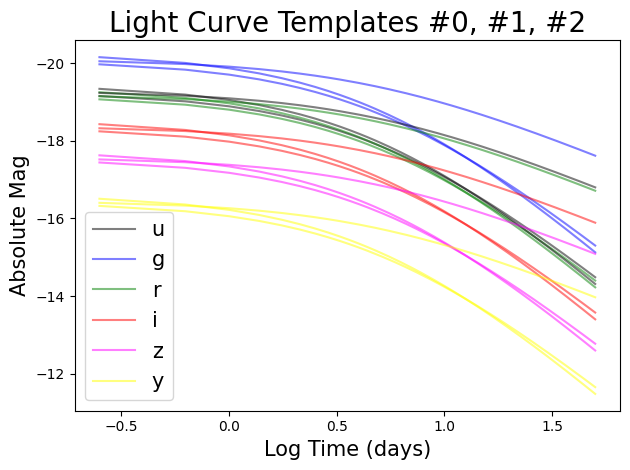

In [239]:
#plot light curves from pkl file if desired
shared_utils.plot_template_lcs(templates_file, num=3, use_log_time=True, plot_overlap=True)

[INFO] Generating population and saving to /Users/andradenebula/Documents/Research/Transient_Metrics/Multi_Transient_Metrics_Hub/output/LFBOTs/LFBOTs_den_4.2e-07_d_None-None_Mpc_z_0.00226-0.3_ext_True_kcor_True_None_population.pkl
[INFO] z_min = 0.00226 -> d_min = 10.008475172186687 Mpc
[INFO] z_max = 0.30000 -> d_max = 1232.706667272352661 Mpc
Simulated 32655 events using rate_density = 4.2e-07
Len ra before masking:  32655


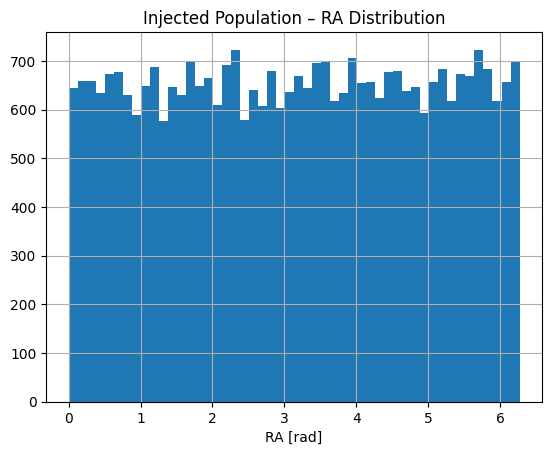

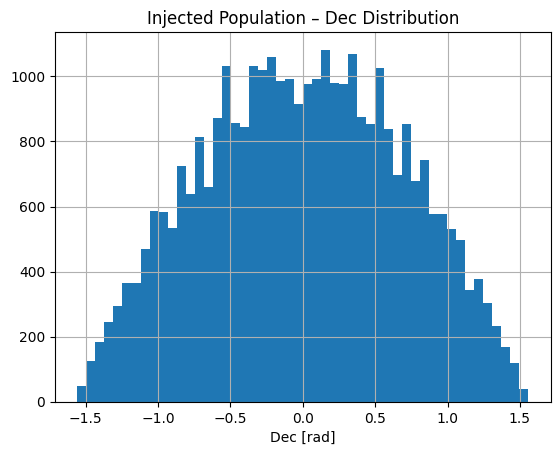

initial peak times:  [ 126.4253556  3011.75839955 1879.9482674  ... 2105.69929796 2564.32417934
 2721.40869855]
gal_lat_cut is none


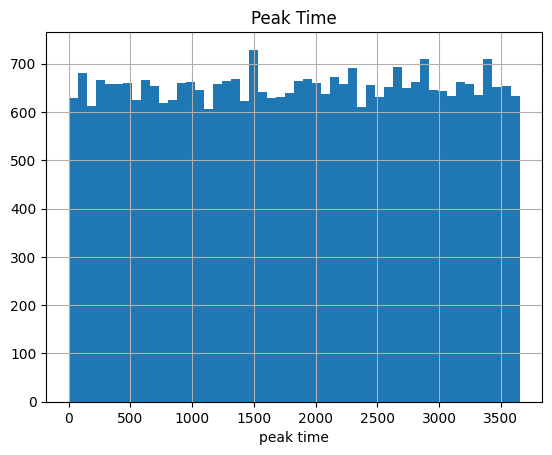

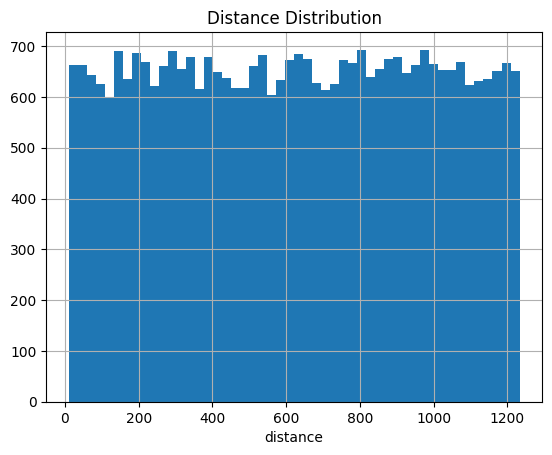

[DEBUG] coords.dec[:5]: [ 55.10793643 -33.51005607 -18.20995686   7.18075578   7.78271439] deg
[DEBUG] coords.dec.unit: deg


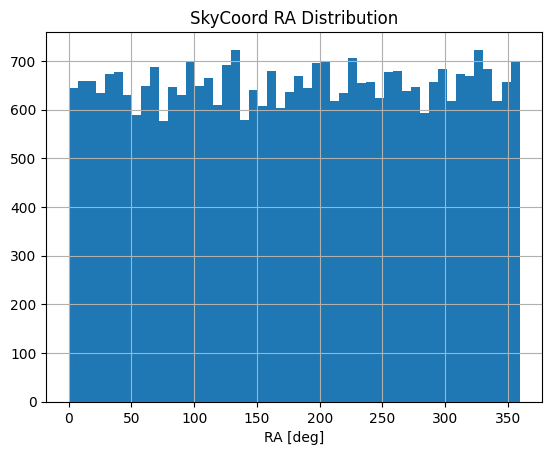

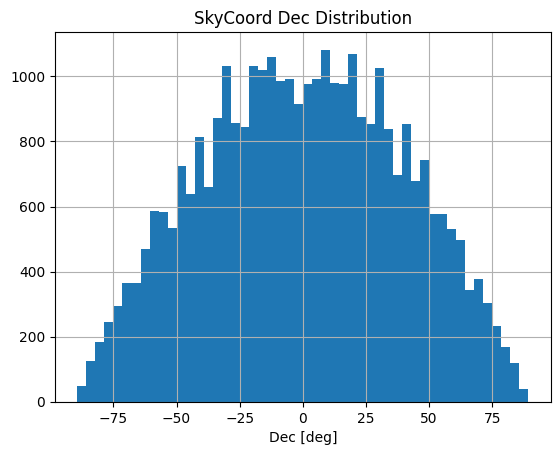

[INFO] Saved atomically to /Users/andradenebula/Documents/Research/Transient_Metrics/Multi_Transient_Metrics_Hub/output/LFBOTs/LFBOTs_den_4.2e-07_d_None-None_Mpc_z_0.00226-0.3_ext_True_kcor_True_None_population.pkl
DEBUG: type(peak_times) = <class 'numpy.ndarray'>
DEBUG: shape(peak_times) = (32655,)


In [241]:
# Load or generate population slicer
slicer = shared_utils.load_or_generate_population(use_extinction=use_extinction,
    lc_model=shared_lc_model,
    t_start=t_start,
    t_end=t_end,
    d_min=d_min,
    d_max=d_max,
    z_min=z_min,
    z_max=z_max,
    seed=42,
    num_lightcurves=num_lightcurves, #technically should read this from the file
    gal_lat_cut=gal_lat_cut,
    rate_density=rate_density,
    pop_file=pop_file,
    generate_new=generate_new_pop,
    make_debug_plots=make_debug_plots,
    use_kcorrect=use_kcorrect,
    k_correct_type=k_correct_type,
    k_correct_arg=k_correct_arg,
)


In [242]:
shared_utils.get_kcorrection_powerlaw(np.array([1,4]), 'y', spectral_index=-.75)

array([1.31700623, 3.05799377])

In [243]:
shared_utils.get_kcorrection_blackbody(np.array([.05,1,2,4]), 'u', temperature=10000)

array([ 0.10874672,  2.73033789,  6.06364269, 13.38102463])

In [244]:
import importlib, shared_utils
importlib.reload(shared_utils)


<module 'shared_utils' from '/Users/andradenebula/Documents/Research/Transient_Metrics/Multi_Transient_Metrics_Hub/shared_utils.py'>

## All 10 years


--- Running four_roll_v4.3.1_10yrs ---

Inspecting one obs_record before saving to CSV:
mjd_obs         | type: <class 'list'> | length: 754
mag_obs         | type: <class 'list'> | length: 754
snr_obs         | type: <class 'list'> | length: 754
filter          | type: <class 'list'> | length: 754
diag_sample_mjd | type: <class 'list'> | length: 9
diag_sample_mag | type: <class 'list'> | length: 9
diag_sample_snr | type: <class 'list'> | length: 9
diag_sample_filter | type: <class 'list'> | length: 9
per_filter_min_mag | type: <class 'dict'> | length: 6
max_flux_change_sigma | type: <class 'dict'> | length: 6
any_flux_change_gt3 | type: <class 'bool'> | value: False
first_det_mjd   | type: <class 'float'> | value: nan
last_det_mjd    | type: <class 'float'> | value: nan
fade_time_days  | type: <class 'float'> | value: nan
sid_duplicate   | type: <class 'numpy.int64'> | value: 1
file_indx       | type: <class 'numpy.int64'> | value: 34
ra              | type: <class 'numpy.float64'> |

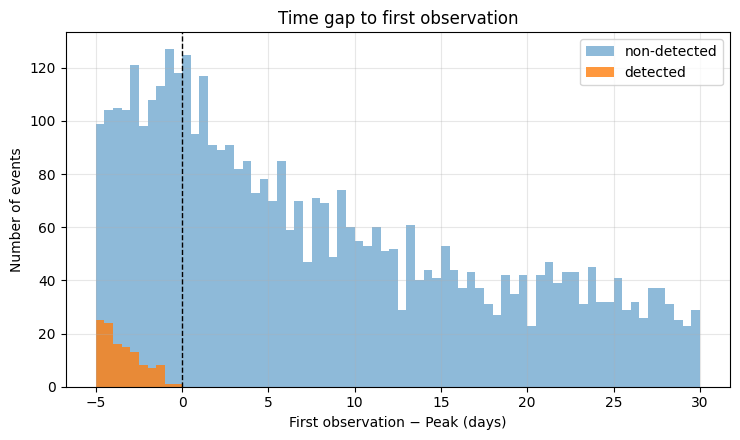

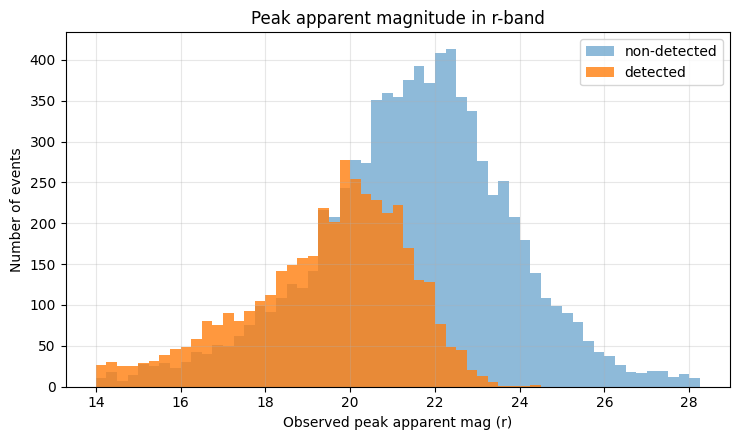

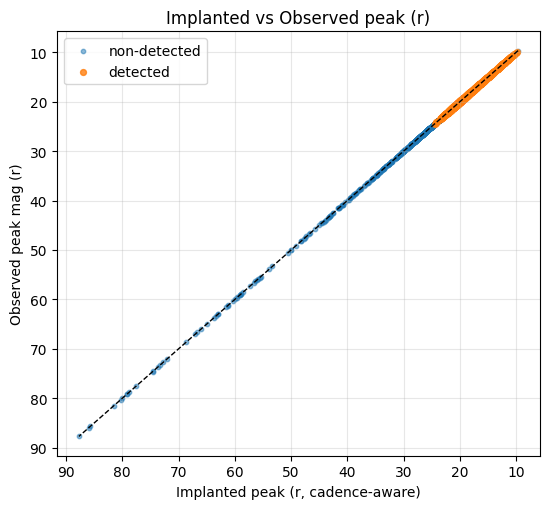

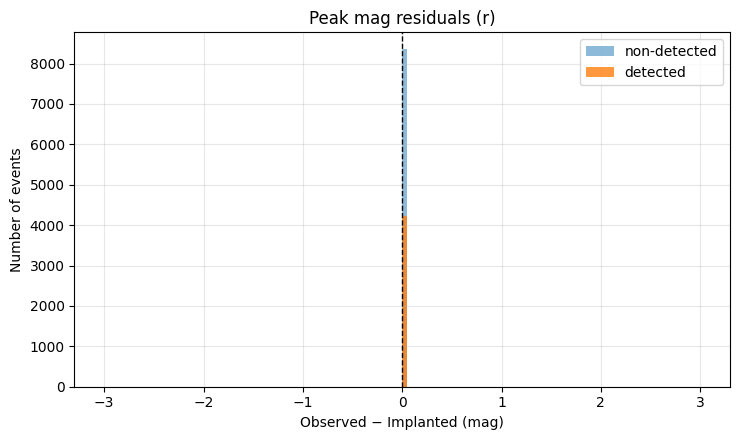

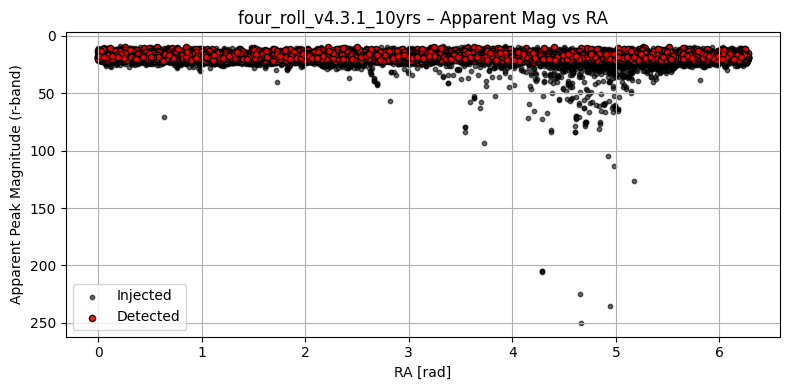

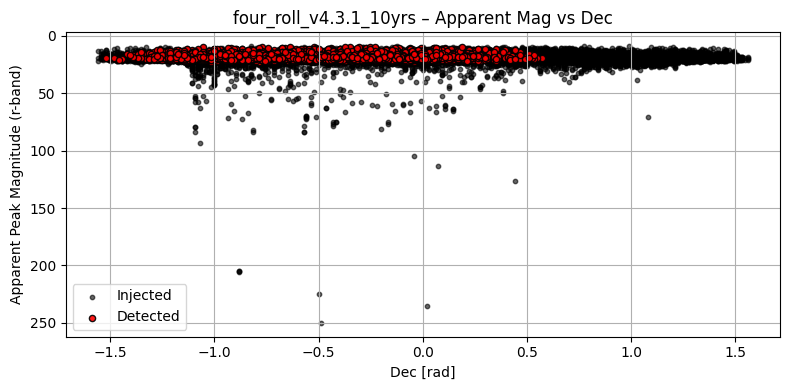

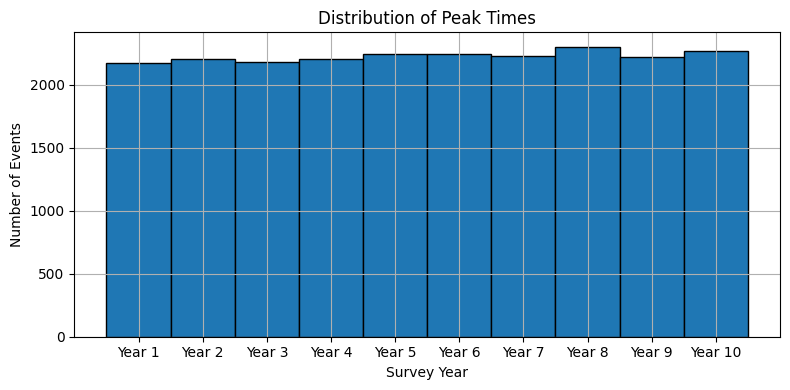

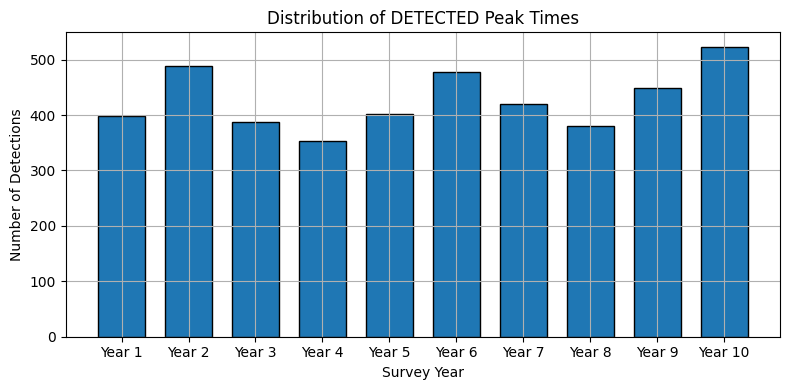

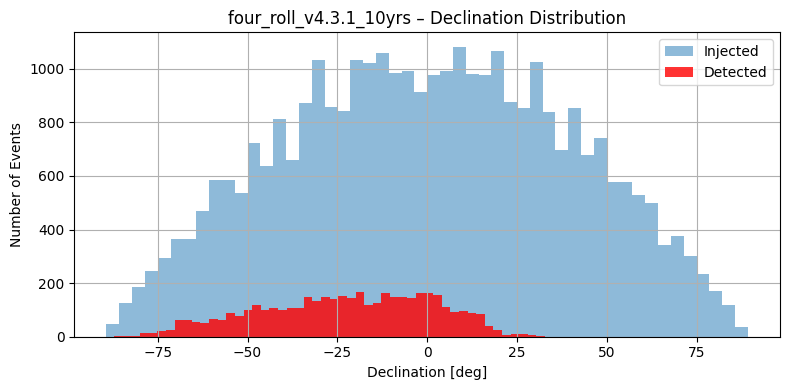

[CLEANUP] Removing temp directory: /Users/andradenebula/Documents/Research/Transient_Metrics/Multi_Transient_Metrics_Hub/output/LFBOTs/Metric_temp_four_roll_v4.3.1_10yrs


In [246]:
#run detection metric
df_obs = shared_utils.run_detect(metric, 
                                 slicer, 
                                 cadences, 
                                 shared_lc_model, 
                                 db_dir, storage_dir, 
                                 df_file, 
                                 ignore_triples=ignore_triples, 
                                 debug=True, plot=True, 
                                 clean_temp=clean_temp,
                                 use_kcorrect=use_kcorrect,
                                 k_correct_type=k_correct_type,
                                 k_correct_arg=k_correct_arg,
                                 use_extinction=use_extinction)



In [247]:
cols = ["sid",
        "injected_peak_ebv_mag_r",
        "injected_peak_ebv_mag_r_cadence",
        "eval_peak_mag"]
print(df_obs[cols].head())

print("Residuals vs cadence-aware (should ~0):",
      np.nanmedian(df_obs["eval_peak_mag"] - df_obs["injected_peak_ebv_mag_r_cadence"]))

print("Cadence penalty (cadence − global):",
      np.nanmedian(df_obs["injected_peak_ebv_mag_r_cadence"] - df_obs["injected_peak_ebv_mag_r"]))


   sid  injected_peak_ebv_mag_r  injected_peak_ebv_mag_r_cadence  \
0    1                18.391526                              NaN   
1    2                20.609923                        21.619325   
2    3                21.176206                              NaN   
3    4                15.729507                        17.059811   
4    5                20.332252                        22.316902   

   eval_peak_mag  
0            NaN  
1      21.619325  
2      22.826753  
3      17.048027  
4      22.316902  
Residuals vs cadence-aware (should ~0): -0.3571463181309582
Cadence penalty (cadence − global): 1.407833485858541


In [248]:

#choose what to run in run_multi_metrics
# we can remove historical if we want
multi_metrics = metric.get_multi_metrics(shared_lc_model, include=['detect','characterize'], use_extinction=use_extinction, use_kcorrect=use_kcorrect, k_correct_type=k_correct_type, k_correct_arg=k_correct_arg)


# Apply consistent diagnostics knobs
for m in multi_metrics:
    m.diag_store = True
    m.diag_sample_rate = 0.01
    m.diag_per_event_cap = 30
    m.diag_min_snr = 3
    m.diag_max_mag = None




--- Running four_roll_v4.3.1_10yrs ---
(2,)
[<local_LFBOTmetric.Detect_Metric object at 0x4bce413d0>, <local_LFBOTmetric.LFBOTCharacterizeMetric object at 0x4bce41ed0>]
                                         Sum                     run  \
four_roll_v4.3.1_10yrs_Detect_Metric  4276.0  four_roll_v4.3.1_10yrs   

                                      n_events_full_sky  
four_roll_v4.3.1_10yrs_Detect_Metric              32655  
[DEBUG] Detected RA, Dec: 6.33, 3.58
[DEBUG] Detected RA, Dec: 53.00, -56.64
[DEBUG] Detected RA, Dec: 79.45, -24.62


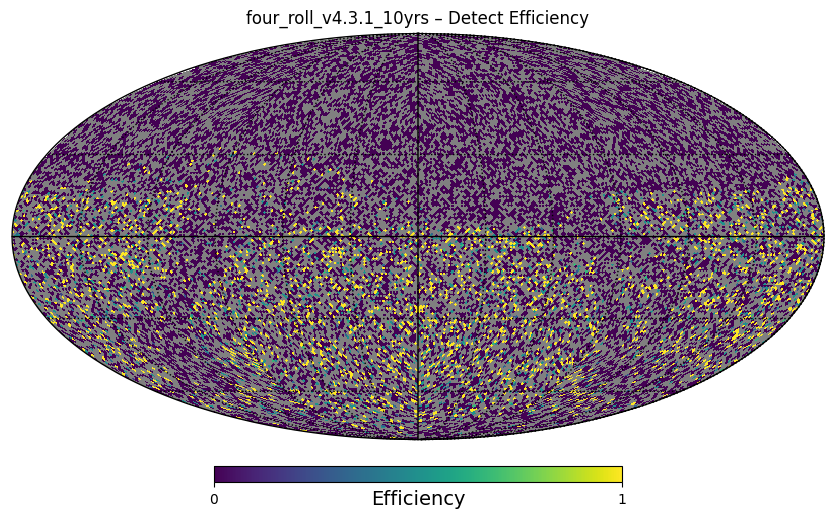

[DEBUG] Detected RA, Dec: 277.79, -51.26
[DEBUG] Detected RA, Dec: 357.19, 7.78
[DEBUG] Detected RA, Dec: 122.62, -60.43
[DEBUG] Detected RA, Dec: 315.00, -33.51
[DEBUG] Detected RA, Dec: 67.50, -29.31
[DEBUG] Detected RA, Dec: 92.65, -77.55
[DEBUG] Detected RA, Dec: 97.73, -1.19
[DEBUG] Detected RA, Dec: 84.38, 8.99
[DEBUG] Detected RA, Dec: 136.41, 6.58
[DEBUG] Detected RA, Dec: 119.21, -47.36
[DEBUG] Detected RA, Dec: 5.77, -61.19
[DEBUG] Detected RA, Dec: 169.74, -47.36


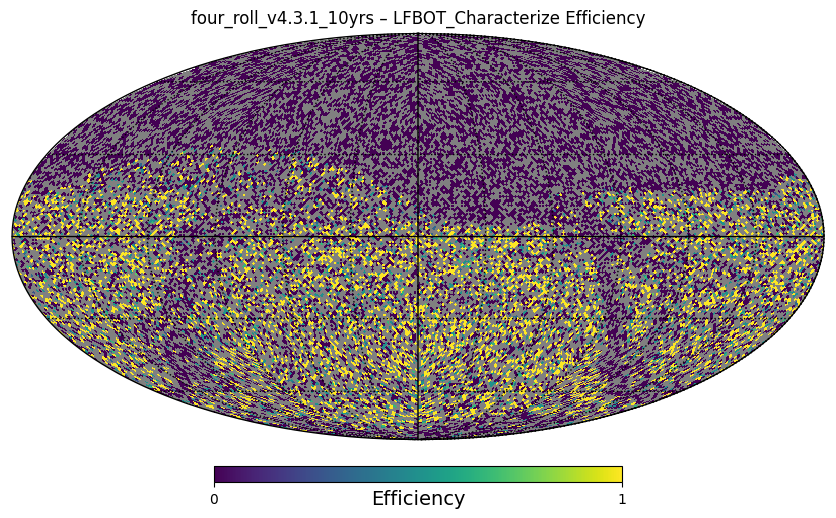

[CLEANUP] Removing temp directory: /Users/andradenebula/Documents/Research/Transient_Metrics/Multi_Transient_Metrics_Hub/output/LFBOTs/Metric_temp_four_roll_v4.3.1_10yrs
saved summary to  /Users/andradenebula/Documents/Research/Transient_Metrics/Multi_Transient_Metrics_Hub/output/LFBOTs/LFBOTs_den_4.2e-07_d_None-None_Mpc_z_0.00226-0.3_ext_True_kcor_True_None_None_multi_summary.csv


In [249]:
summary_df_1 = shared_utils.run_multi_metrics(multi_metrics, 
                                              slicer, cadences, shared_lc_model, 
                                              db_dir, storage_dir, 
                                              summary_filename=summary_filename, ignore_triples=False, plot=True, clean_temp=clean_temp, use_extinction=use_extinction)

In [250]:
summary_df_1

,Sum,run,n_events_full_sky
four_roll_v4.3.1_10yrs_Detect_Metric,4276.0,four_roll_v4.3.1_10yrs,32655
four_roll_v4.3.1_10yrs_LFBOTCharacterizeMetric,8604.0,four_roll_v4.3.1_10yrs,32655


In [251]:
import pickle
with open(pop_file, 'rb') as f:
    sp = pickle.load(f)
missing = [f'peak_app_mag_ebv_{f}' for f in ('u','g','r','i','z','y') if f'peak_app_mag_ebv_{f}' not in sp]
print("Missing peak columns:", missing or "None — all present")


Missing peak columns: None — all present


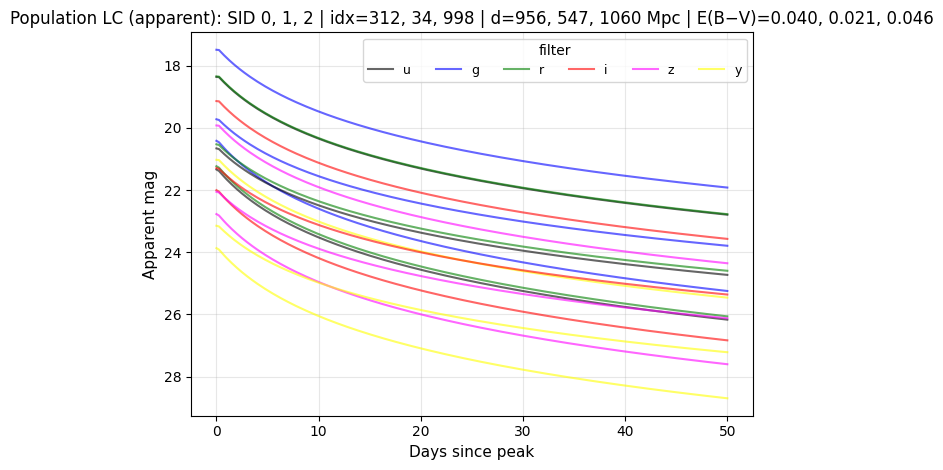

In [252]:
shared_utils.plot_population_lcs(
    pop_file=pop_file,
    lc_model=shared_lc_model,   # or pass templates_file=templates_file
    fast_peaks=False,
    use_kcorrect=use_kcorrect,
    k_correct_type=k_correct_type,
    k_correct_arg=k_correct_arg,
    num=3,
    days_before=0.0,            # see note below
    days_after=100.0,
    use_log_time=False,
    overlap=True
)
